# 🌧️ Rainfall Prediction using Machine Learning
Algorithm : Random Forest Regressor

Dataset   : fall.csv  (2362 records)


# ─────────────────────────────────────────────
# Step 1: Import Libraries
# ─────────────────────────────────────────────

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# ─────────────────────────────────────────────
# Step 2: Load Dataset
# ─────────────────────────────────────────────


In [136]:
ds = pd.read_csv("fall.csv")

print("Dataset Shape:", ds.shape)
print("\nFirst 5 Records:")
ds.head()

Dataset Shape: (2362, 10)

First 5 Records:


,year,month,day,tempavg,DPavg,humidity avg,SLPavg,visibilityavg,windavg,Rainfall
0,2011,2,13,21,13,60,1009,3,5,0.0
1,2011,2,14,21,18,75,1009,3,5,0.0
2,2011,2,15,22,18,75,1010,3,10,0.0
3,2011,2,16,23,21,86,1011,3,8,0.0
4,2011,2,17,23,19,75,1011,3,8,0.0


# ─────────────────────────────────────────────
# Step 3: Data Preprocessing
# ─────────────────────────────────────────────

In [137]:
# Drop columns not needed for prediction
ds = ds.drop(['month', 'day'], axis=1)

print("After Dropping 'month' and 'day':")
ds.head()

# Check for missing values
print("\nMissing Values per Column:")
print(ds.isnull().sum())

After Dropping 'month' and 'day':

Missing Values per Column:
year             0
tempavg          0
DPavg            0
humidity avg     0
SLPavg           0
visibilityavg    0
windavg          0
Rainfall         0
dtype: int64


# ─────────────────────────────────────────────
# Step 4: Feature & Target Selection
# ─────────────────────────────────────────────

In [138]:
# Features: year, tempavg, DPavg, humidity avg, SLPavg, visibilityavg, windavg
x = ds.iloc[:, :7].values

# Target: Rainfall (mm)
y = ds.iloc[:, 7].values

print(f"\nFeature matrix shape : {x.shape}")
print(f"Target vector shape  : {y.shape}")


Feature matrix shape : (2362, 7)
Target vector shape  : (2362,)


# ─────────────────────────────────────────────
# Step 5: Train-Test Split   (80% train | 20% test)
# ─────────────────────────────────────────────

In [139]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=0
)

print(f"\nTotal Dataset : {ds.shape[0]} rows")
print(f"Training Set  : {x_train.shape[0]} rows")
print(f"Testing Set   : {x_test.shape[0]} rows")


Total Dataset : 2362 rows
Training Set  : 1889 rows
Testing Set   : 473 rows


# ─────────────────────────────────────────────
# Step 6: Feature Scaling
# ─────────────────────────────────────────────

In [140]:
# Fit scaler ONLY on training data to prevent data leakage
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)       # transform only (no fit)

# ─────────────────────────────────────────────
# Step 7: Model Building — Random Forest Regressor
# ─────────────────────────────────────────────

In [141]:
regressor = RandomForestRegressor(
    n_estimators=500,       # number of decision trees
    max_features='sqrt',    # features considered per split
    random_state=0
)

regressor.fit(x_train_scaled, y_train)
print("\n✅ Model training complete.")


✅ Model training complete.


# ─────────────────────────────────────────────
# Step 8: Prediction & Model Evaluation
# ─────────────────────────────────────────────


In [142]:
# Predict on scaled data (consistent with training)
ypred_train = regressor.predict(x_train_scaled)
ypred_test  = regressor.predict(x_test_scaled)

# R² Score
train_accuracy = r2_score(y_train, ypred_train)
test_accuracy  = r2_score(y_test,  ypred_test)

print(f"\nTraining Accuracy (R²) : {train_accuracy:.2f}")
print(f"Testing Accuracy  (R²) : {test_accuracy:.2f}")


Training Accuracy (R²) : 0.85
Testing Accuracy  (R²) : 0.29


# ─────────────────────────────────────────────
# Step 9: Feature Importance
# ─────────────────────────────────────────────

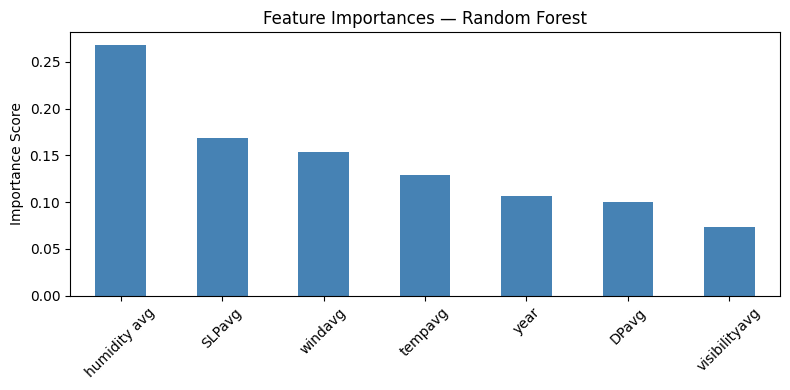


Feature Importances:
humidity avg     0.268009
SLPavg           0.168986
windavg          0.154007
tempavg          0.129259
year             0.106264
DPavg            0.100255
visibilityavg    0.073219
dtype: float64


In [143]:
feature_names = ['year', 'tempavg', 'DPavg', 'humidity avg',
                 'SLPavg', 'visibilityavg', 'windavg']

importances = pd.Series(regressor.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances_sorted.plot(kind='bar', color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(importances_sorted)

# ─────────────────────────────────────────────
# Step 10: Visualizations — Feature vs Rainfall
# ─────────────────────────────────────────────


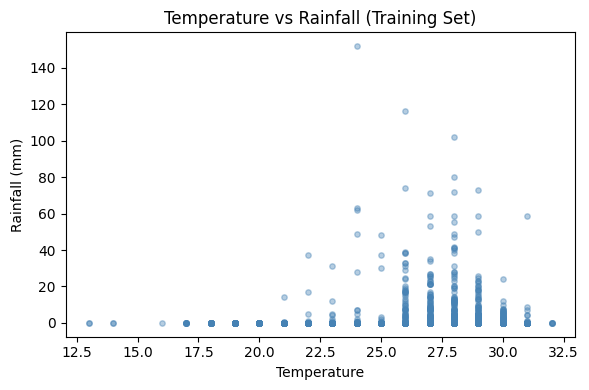

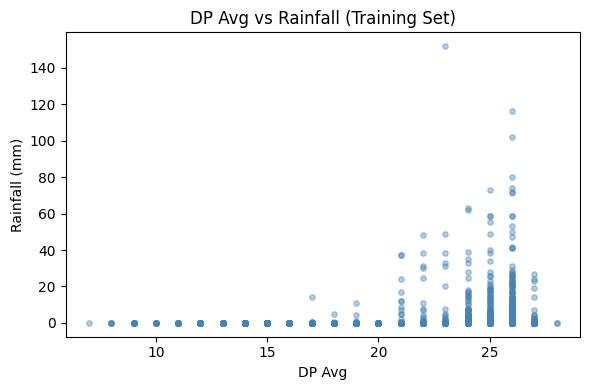

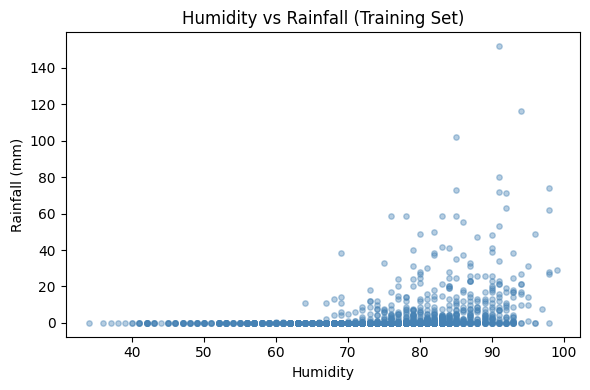

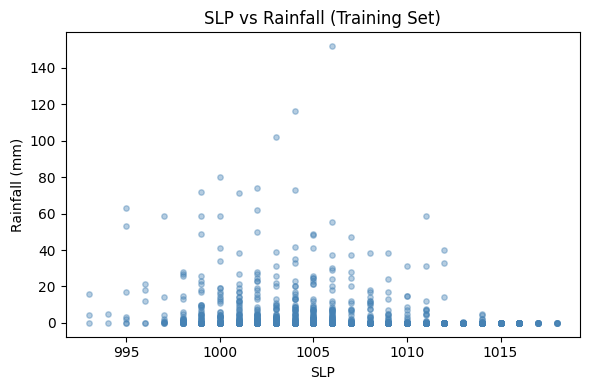

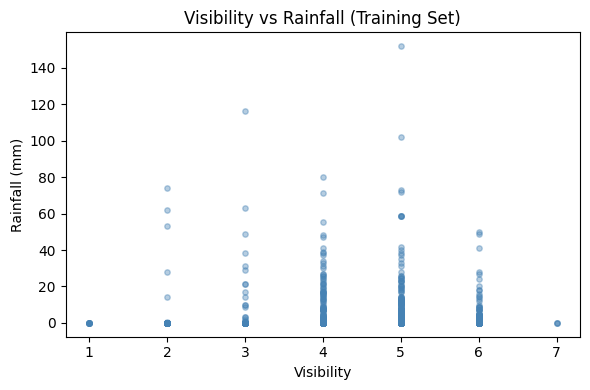

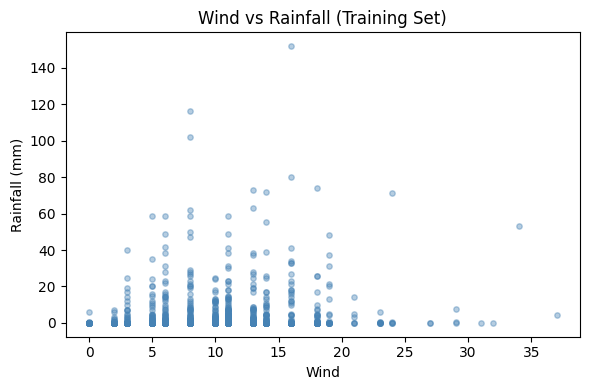

In [144]:
features = ['Temperature', 'DP Avg', 'Humidity', 'SLP', 'Visibility', 'Wind']

for i, feature in enumerate(features):
    plt.figure(figsize=(6, 4))
    plt.scatter(x_train[:, i + 1], y_train, color='steelblue', alpha=0.4, s=15)
    plt.title(f'{feature} vs Rainfall (Training Set)')
    plt.xlabel(feature)
    plt.ylabel('Rainfall (mm)')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────
# Step 11: Correlation Heatmap
# ─────────────────────────────────────────────



Correlation Matrix:
                   year   tempavg     DPavg  humidity avg    SLPavg  \
year           1.000000  0.090248  0.044044     -0.091357  0.085676   
tempavg        0.090248  1.000000  0.863829      0.340977 -0.674395   
DPavg          0.044044  0.863829  1.000000      0.731021 -0.758224   
humidity avg  -0.091357  0.340977  0.731021      1.000000 -0.574413   
SLPavg         0.085676 -0.674395 -0.758224     -0.574413  1.000000   
visibilityavg -0.082626  0.704721  0.604098      0.173502 -0.557946   
windavg        0.110007  0.233133  0.213889      0.101864 -0.378632   
Rainfall       0.041735  0.070369  0.177919      0.297830 -0.242161   

               visibilityavg   windavg  Rainfall  
year               -0.082626  0.110007  0.041735  
tempavg             0.704721  0.233133  0.070369  
DPavg               0.604098  0.213889  0.177919  
humidity avg        0.173502  0.101864  0.297830  
SLPavg             -0.557946 -0.378632 -0.242161  
visibilityavg       1.000000  0.2

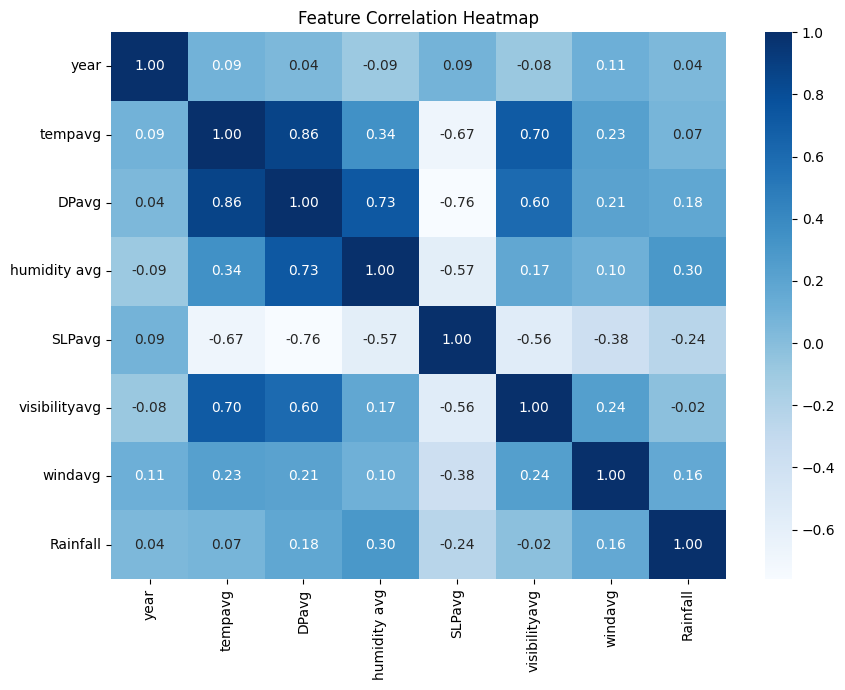

In [145]:
print("\nCorrelation Matrix:")
print(ds.corr())

plt.figure(figsize=(9, 7))
sns.heatmap(ds.corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────
# Step 12: Predict a New Data Record
# ─────────────────────────────────────────────────────

In [146]:
# Input format: [year, tempavg, DPavg, humidity, SLP, visibility, wind]
new_input = np.array([[2020, 18, 16, 65, 1013, 6, 8]])

# Scale the new input using the SAME scaler fitted on training data
new_input_scaled = scaler.transform(new_input)

ypred1 = regressor.predict(new_input_scaled)
print(f"\nPredicted Rainfall : {round(ypred1[0], 2)} mm")


Predicted Rainfall : 0.13 mm


# ─────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────

In [147]:
print("\n" + "─" * 46)
print("  MODEL SUMMARY")
print("─" * 46)
print(f"  Algorithm          : Random Forest Regressor")
print(f"  Number of Trees    : 500")
print(f"  Training Size      : {x_train.shape[0]} records")
print(f"  Testing Size       : {x_test.shape[0]} records")
print(f"  Training Accuracy  : {train_accuracy:.2f}")
print(f"  Testing Accuracy   : {test_accuracy:.2f}")
print(f"  Predicted Rainfall : {round(ypred1[0], 2)} mm")
print("─" * 46)


──────────────────────────────────────────────
  MODEL SUMMARY
──────────────────────────────────────────────
  Algorithm          : Random Forest Regressor
  Number of Trees    : 500
  Training Size      : 1889 records
  Testing Size       : 473 records
  Training Accuracy  : 0.85
  Testing Accuracy   : 0.29
  Predicted Rainfall : 0.13 mm
──────────────────────────────────────────────



# Done